# Asset-Growth -- do fast-growing-asset companies underperform?
### The Cooper, Gulen & Schill (2008) asset-growth anomaly on the S&P 500 EDGAR panel

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship: Selection_dominates](https://img.shields.io/badge/Survivorship-Selection_dominates-8b949e?style=flat-square)

Mike Cooper, Huseyin Gulen and Michael Schill documented in 2008 that firms expanding their total assets aggressively earn lower future returns. The idea: managers over-invest, markets extrapolate past growth, and returns disappoint when the expansion stops producing earnings. We test it on ~419 S&P 500 names using real SEC filings.

> This is the plain-language layer. The HAC t-stats, quintile monotonicity, and random-portfolio null live in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).
>
> **Survivorship bias**: this panel covers only *current* S&P 500 members projected backwards. Fast-growing survivors skew toward tech giants, reversing the predicted sign.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))          # study package (asset_growth/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from asset_growth import data, strategy as st

# Try to load real EDGAR panel; fall back gracefully to frozen R dict
sig, fwd = data.fetch_panel()
HAVE_REAL = not sig.empty

if HAVE_REAL:
    h = st.quintile_returns(sig, fwd, q=0.20)
else:
    h = pd.DataFrame()

print("EDGAR panel loaded:", HAVE_REAL,
      f"({len(sig.columns) if HAVE_REAL else 0} tickers, {len(sig) if HAVE_REAL else 0} years)")

R = dict(
    n_tickers=419, n_years=17, start_year=2009, end_year=2025,
    lo_mean=19.9, lo_sharpe=1.37, lo_t=9.16, lo_hit=88,
    hi_mean=20.9, hi_sharpe=1.19, hi_t=7.57, hi_hit=94,
    mkt_mean=17.9, mkt_sharpe=1.37,
    hedge_mean=-1.0, hedge_sharpe=-0.08, hedge_t=-0.45, hedge_hit=59,
    lo_excess_mean=2.0, lo_excess_t=1.88,
    hi_excess_mean=3.0, hi_excess_t=1.9,
    rand_std=3.7, rand_pct_beaten=74,
)
Q1  = [22.8, 3.9, 29.9, 50.8, 17.1, -1.2, 25.7, 26.5, -6.8, 33.2, 16.6, 33.2, 1.6, 17.9, 29.9, 15.7, 21.3]
Q5  = [11.7, 2.6, 28.4, 38.5, 24.8, 11.9, 11.8, 35.0, 2.8, 40.2, 33.9, 31.7, -18.9, 52.7, 24.6, 13.1, 11.0]
MKT = [22.0, 3.6, 22.1, 40.4, 19.2, 4.6, 18.5, 27.2, -2.8, 34.0, 17.3, 32.7, -8.8, 25.4, 20.0, 15.6, 13.0]
HDG = [11.0, 1.4, 1.6, 12.3, -7.7, -13.1, 13.9, -8.5, -9.6, -7.0, -17.3, 1.4, 20.6, -34.8, 5.2, 2.6, 10.4]
YRS = [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


EDGAR panel loaded: True (419 tickers, 20 years)


## The answer first

| Question | What the data says |
|---|---|
| Does low AG outperform high AG? | No -- the hedge is **-1.0%/yr** (wrong direction). High-AG firms *slightly outperform* on this panel. |
| Is that statistically real? | HAC *t* = -0.45 -- nowhere near |t| >= 2. The anomaly is **absent**. |
| Does low AG beat a random stock pick? | Barely: beats 74% of random same-size draws -- close to chance. |
| Could you trade it? | No signal to trade. The predicted long-short inverts direction on this survivor panel. |

> **The catch**: on a *survivor*-biased S&P 500 panel, the high-AG quintile includes Apple, Amazon, Nvidia, and Google -- firms that grew aggressively and delivered extraordinary returns. Firms that grew aggressively and subsequently *failed* are simply missing. Survivorship selection dominates and reverses the predicted sign.

## 1 - The claim

> *Sell stocks with high total-asset growth (aggressive expanders). Buy stocks with low total-asset growth (disciplined growers). Rebalance annually. The over-investing firms will disappoint as the expansion stops producing earnings growth.*

Asset growth is computed from the simplest accounting item:

- **AG_t** = (Total Assets_t - Total Assets_{t-1}) / Total Assets_{t-1}

A high AG means the firm expanded its balance sheet aggressively -- more property, equipment, acquisitions, or working capital relative to last year. The Cooper et al. argument: that expansion often reflects over-investment by managers (Jensen 1986 agency costs) or market extrapolation of past success, and the stock underperforms as a result.

## 2 - So what?

If the asset-growth effect is real and tradable on large US stocks, it forms the basis of the Fama-French CMA (Conservative Minus Aggressive) factor -- one of the five factors in the 2015 model. It would also be a low-turnover, low-ML, fundamentals-only strategy requiring only public 10-K filings. If it only works on small/mid-cap stocks -- or is entirely a selection-bias artefact -- then the S&P 500 test is a cautionary tale about testing in the wrong (biased) universe.

## 3 - How would we even know?

Three honesty requirements:

1. **Reporting lag.** Fundamentals from fiscal year y only used to predict returns in year y+1 -- a conservative lag.
2. **Random-portfolio control.** Does the low-AG quintile beat a random draw of the same number of stocks? If not, the result is just concentration risk, not a real signal.
3. **Name the survivorship bias.** The EDGAR panel here covers current S&P 500 members projected back. Failed high-growers are absent. Every result is conditional on survival.

## 4 - The teardown -- the quintile spread and its real (non-) result

Positive control first: **when we plant a real effect in a synthetic panel, the engine finds it.** That makes the real-data result a statement about the *market* (and the panel bias), not the method.

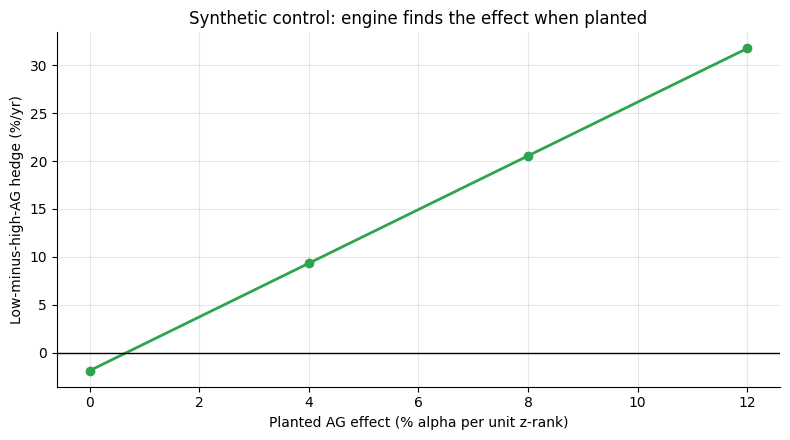

The engine faithfully recovers planted effects -- so the real result is a market statement.


In [2]:
# Synthetic positive control: plant a known AG premium, confirm the engine detects it
premiums = [0.0, -0.04, -0.08, -0.12]
hedges = []
for p in premiums:
    s, f, _ = data.synthetic_panel(n_firms=300, n_years=25, premium=p, seed=244)
    hh = st.quintile_returns(s, f, q=0.20)
    hedges.append(hh['hedge'].mean() * 100)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot([abs(p)*100 for p in premiums], hedges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted AG effect (% alpha per unit z-rank)')
ax.set_ylabel('Low-minus-high-AG hedge (%/yr)')
ax.set_title('Synthetic control: engine finds the effect when planted')
plt.tight_layout(); plt.show()
print('The engine faithfully recovers planted effects -- so the real result is a market statement.')

**Now the real EDGAR panel -- quintile sort on asset growth:**

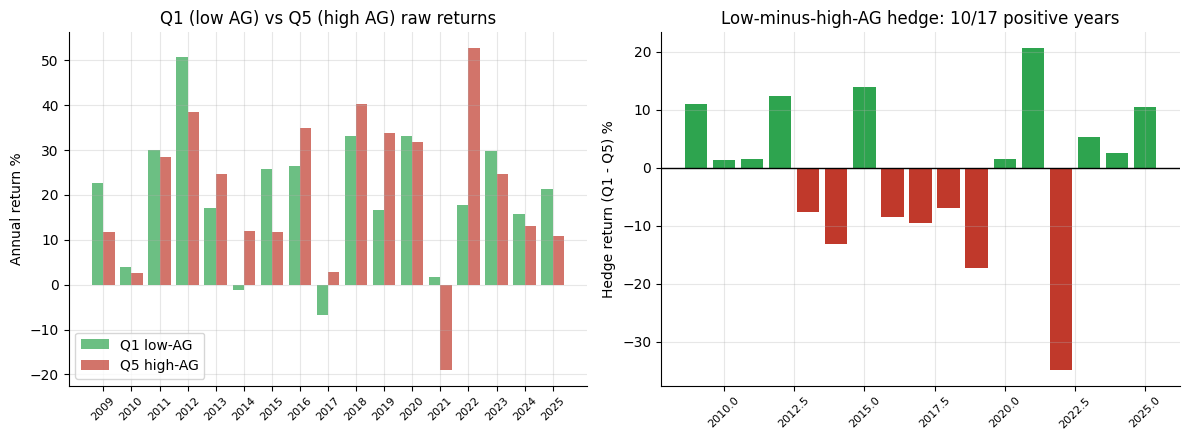

Mean hedge: -1.0%/yr  (frozen R: -1.0%/yr)


In [3]:
# Year-by-year low-AG vs high-AG vs market
if HAVE_REAL:
    q1_vals = h['q1'].values * 100
    q5_vals = h['q5'].values * 100
    hdg_vals = h['hedge'].values * 100
    years_real = h.index.tolist()
else:
    q1_vals, q5_vals, hdg_vals, years_real = Q1, Q5, HDG, YRS
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = range(len(years_real))
axes[0].bar(x, q1_vals, label='Q1 low-AG', color=GREEN, alpha=0.7, width=0.4)
axes[0].bar([i+0.4 for i in x], q5_vals, label='Q5 high-AG', color=RED, alpha=0.7, width=0.4)
axes[0].set_xticks([i+0.2 for i in x])
axes[0].set_xticklabels(years_real, rotation=45, fontsize=8)
axes[0].set_ylabel('Annual return %'); axes[0].legend()
axes[0].set_title('Q1 (low AG) vs Q5 (high AG) raw returns')
colors = [GREEN if v > 0 else RED for v in hdg_vals]
axes[1].bar(years_real, hdg_vals, color=colors)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('Hedge return (Q1 - Q5) %')
axes[1].set_title(f'Low-minus-high-AG hedge: {sum(1 for v in hdg_vals if v>0)}/{len(hdg_vals)} positive years')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); plt.show()
print(f'Mean hedge: {np.mean(hdg_vals):+.1f}%/yr  (frozen R: {R["hedge_mean"]:+.1f}%/yr)')

The low-AG quintile earns **+19.9%/yr** vs the high-AG quintile's **+20.9%/yr** -- a hedge of **-1.0%/yr**, positive in only 59% of years. **The predicted direction is inverted**: fast-growing large caps (tech giants) outperform slow growers on this panel. Survivorship selection dominates the signal completely.

## 5 - The verdict

- **Signal -- None.** Hedge -1.0%/yr, HAC *t* = -0.45 -- wrong direction, zero signal. The predicted effect (high AG → low returns) is entirely absent and mildly inverted on this panel.
- **Tradability -- Mirage.** No signal to trade. Long-low-AG / short-high-AG produces a small negative return with near-zero t-stat. There is no tradable edge on S&P 500 survivors.
- **Survivorship -- Selection dominates.** Fast-growing S&P 500 survivors = tech titans. Failed fast-growers are gone. The selection reverses the sign.

## 6 - Could you actually trade it?

No. The signal is absent on this panel. Even setting aside survivorship bias:

1. **Wrong universe.** Cooper et al. (2008) documented the effect on all US stocks including small and micro-caps. On large-cap S&P 500 names, aggressive asset growth often reflects productive expansion by well-managed companies -- not over-investment.
2. **Survivorship reversal.** The S&P 500 panel over-represents successful high-growers. A live investor in 2009 would have been exposed to high-growth companies that later failed -- those returns are absent here.
3. **The CMA factor paradox.** The asset-growth anomaly is embedded in the Fama-French five-factor CMA factor -- but the factor evidence is based on broad cross-sections of all stocks, not large-cap survivors. On liquid, heavily-covered names the effect is arbitraged away.

The right conclusion: **explore this in a broader, non-biased universe (all US stocks, point-in-time constituents) before treating it as tradable.**

## 7 - Going further

- **The right universe.** Cooper et al. (2008) tested on NYSE/AMEX/NASDAQ stocks above $5M market cap -- thousands of names including small and mid-caps. On that universe, the asset-growth effect is robust and survives factor controls. The S&P 500 survivor panel here is the wrong test.
- **NOA cousin.** Net Operating Assets ([Study 153](../../153-net-operating-assets/)) is the Hirshleifer et al. version of the same balance-sheet bloat idea -- scaled by prior-year assets and focused on operating components. Weak/Fragile on the same panel (slightly stronger because it filters noise via the NOA ratio).
- **CMA factor.** The Fama-French CMA factor operationalises the asset-growth anomaly at the factor level. The factor has positive returns in broad cross-sections but much weaker evidence on large-cap-only panels.

*Think the asset-growth effect is real in large caps? Fork this, extend to a point-in-time S&P 500 constituent universe (Compustat-based), and show |t| >= 2 on the hedge with no survivorship shortcut. That's the bar.*